In [ ]:
# ====================================================
# E-Commerce Customer Retention & Churn Analysis
# Author: Cheruku Saritha
# ====================================================

# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# For plotting
import seaborn as sns

# Display charts in notebook
%matplotlib inline

# Display all columns
pd.set_option('display.max_columns', None)

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

# Read the first dataset
df1 = pd.read_csv(
    '/content/drive/MyDrive/Data Analyst Projects/online_retail_II 2009-2010.csv',
    encoding='latin1'
)

# Read the second dataset
df2 = pd.read_csv(
    '/content/drive/MyDrive/Data Analyst Projects/online_retail_II 2010-2011.csv',
    encoding='latin1'
)



# Combine both datasets

In [ ]:
df = pd.concat([df1, df2], ignore_index=True)

# Check the shape

In [ ]:
print("Combined Dataset Shape:", df.shape)

Combined Dataset Shape: (805549, 8)


# Display the first 5 rows

In [ ]:
print(df.shape)

(805549, 12)


View the first few rows:

In [ ]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,revenue,InvoiceYear,Invoicemonth,InvoiceMonthYear
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4,2009,12,2009-12
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,2009,12,2009-12
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,2009,12,2009-12
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.8,2009,12,2009-12
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.0,2009,12,2009-12


View the last few rows:

In [ ]:
df.tail()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
805544,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,09-12-2011 12:50,2.10,12680,France
805545,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,09-12-2011 12:50,4.15,12680,France
805546,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,09-12-2011 12:50,4.15,12680,France
805547,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,09-12-2011 12:50,4.95,12680,France
805548,581587,POST,POSTAGE,1,09-12-2011 12:50,18.00,12680,France


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 805549 entries, 0 to 805548
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Invoice      805549 non-null  int64  
 1   StockCode    805549 non-null  object 
 2   Description  805549 non-null  object 
 3   Quantity     805549 non-null  int64  
 4   InvoiceDate  805549 non-null  object 
 5   Price        805549 non-null  float64
 6   Customer ID  805549 non-null  int64  
 7   Country      805549 non-null  object 
dtypes: float64(1), int64(3), object(4)
memory usage: 49.2+ MB


columns

In [ ]:

df.columns

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country'],
      dtype='object')

Data Validation

Missing Values

In [ ]:
df.isnull().sum()

,0
Invoice,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
Price,0
Customer ID,0
Country,0


Duplicate Rows

In [ ]:
df.duplicated().sum()

np.int64(26124)

Data Types

In [ ]:
df.dtypes

,0
Invoice,int64
StockCode,object
Description,object
Quantity,int64
InvoiceDate,object
Price,float64
Customer ID,int64
Country,object


Unique Customers

In [ ]:
df['Customer ID'].unique()

array([13085, 13078, 15362, ..., 15520, 13298, 12713])

Unique Products

In [ ]:
df['StockCode'].unique()

array(['85048', '79323P', '79323W', ..., '23562', '23561', '23843'],
      dtype=object)

Unique Countries

In [ ]:
df['Country'].unique()

array(['United Kingdom', 'France', 'USA', 'Belgium', 'Australia', 'EIRE',
       'Germany', 'Portugal', 'Denmark', 'Netherlands', 'Poland',
       'Channel Islands', 'Spain', 'Cyprus', 'Greece', 'Norway',
       'Austria', 'Sweden', 'United Arab Emirates', 'Finland', 'Italy',
       'Switzerland', 'Japan', 'Unspecified', 'Nigeria', 'Malta', 'RSA',
       'Singapore', 'Bahrain', 'Thailand', 'Israel', 'Lithuania',
       'West Indies', 'Korea', 'Brazil', 'Canada', 'Iceland', 'Lebanon',
       'Saudi Arabia', 'Czech Republic', 'European Community'],
      dtype=object)

Feature Engineering

Create Revenue

In [ ]:
df['revenue'] = df['Quantity'] * df['Price']
print(df['revenue'])

0          83.40
1          81.00
2          81.00
3         100.80
4          30.00
           ...  
805544     12.60
805545     16.60
805546     16.60
805547     14.85
805548     18.00
Name: revenue, Length: 805549, dtype: float64


Convert Date

In [ ]:
df['InvoiceDate']=pd.to_datetime(df['InvoiceDate'], format="%d-%m-%Y %H:%M")
print(df['InvoiceDate'])

0        2009-12-01 07:45:00
1        2009-12-01 07:45:00
2        2009-12-01 07:45:00
3        2009-12-01 07:45:00
4        2009-12-01 07:45:00
                 ...        
805544   2011-12-09 12:50:00
805545   2011-12-09 12:50:00
805546   2011-12-09 12:50:00
805547   2011-12-09 12:50:00
805548   2011-12-09 12:50:00
Name: InvoiceDate, Length: 805549, dtype: datetime64[ns]


Extract Year

In [ ]:
df['InvoiceYear'] = df['InvoiceDate'].dt.year
print(df['InvoiceYear'])

0         2009
1         2009
2         2009
3         2009
4         2009
          ... 
805544    2011
805545    2011
805546    2011
805547    2011
805548    2011
Name: InvoiceYear, Length: 805549, dtype: int32


Extract Month

In [ ]:
df['Invoicemonth']=df['InvoiceDate'].dt.month
print(df['Invoicemonth'])

0         12
1         12
2         12
3         12
4         12
          ..
805544    12
805545    12
805546    12
805547    12
805548    12
Name: Invoicemonth, Length: 805549, dtype: int32


Extract Month-Year

In [ ]:
df['InvoiceMonthYear'] = df['InvoiceDate'].dt.to_period('M')
print(df['InvoiceMonthYear'])

0         2009-12
1         2009-12
2         2009-12
3         2009-12
4         2009-12
           ...   
805544    2011-12
805545    2011-12
805546    2011-12
805547    2011-12
805548    2011-12
Name: InvoiceMonthYear, Length: 805549, dtype: period[M]


In [ ]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,revenue,InvoiceYear,Invoicemonth,InvoiceMonthYear
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4,2009,12,2009-12
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,2009,12,2009-12
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,2009,12,2009-12
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.8,2009,12,2009-12
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.0,2009,12,2009-12


# 7. Exploratory Data Analysis (EDA)

EDA 1: Monthly Revenue Trend

In [ ]:
MonthlyRevenue= df.groupby('InvoiceMonthYear')['revenue'].sum().reset_index()
print(MonthlyRevenue)

   InvoiceMonthYear      revenue
0           2009-12   686654.160
1           2010-01   557319.062
2           2010-02   506371.066
3           2010-03   699608.991
4           2010-04   594609.192
5           2010-05   599985.790
6           2010-06   639066.580
7           2010-07   591636.740
8           2010-08   604242.650
9           2010-09   831615.001
10          2010-10  1036680.000
11          2010-11  1172336.042
12          2010-12   884591.890
13          2011-01   569445.040
14          2011-02   447137.350
15          2011-03   595500.760
16          2011-04   469200.361
17          2011-05   678594.560
18          2011-06   661213.690
19          2011-07   600091.011
20          2011-08   645343.900
21          2011-09   952838.382
22          2011-10  1039318.790
23          2011-11  1161817.380
24          2011-12   518210.790


Visualization

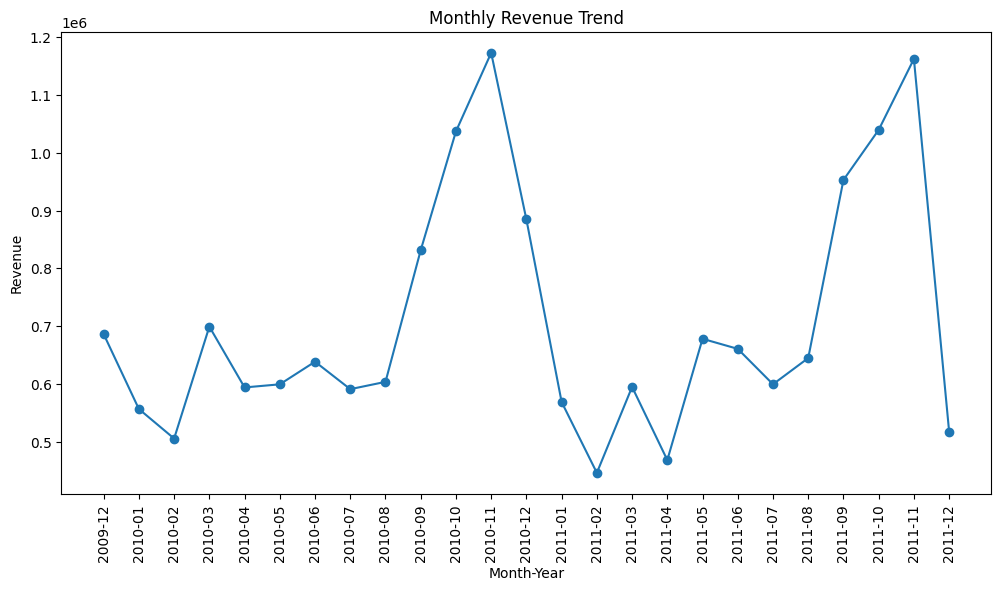

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(MonthlyRevenue['InvoiceMonthYear'].astype(str),
         MonthlyRevenue['revenue'],marker='o')
plt.xticks(rotation=90)
plt.title('Monthly Revenue Trend')
plt.xlabel('Month-Year')
plt.ylabel('Revenue')
plt.show()

EDA 2: Top 10 Countries by Revenue

In [ ]:
Country_Sales= df.groupby('Country')['revenue'].sum().sort_values(ascending=False).head(10).reset_index()
print(Country_Sales)

          Country       revenue
0  United Kingdom  1.472315e+07
1            EIRE  6.216311e+05
2     Netherlands  5.542323e+05
3         Germany  4.312625e+05
4          France  3.552575e+05
5       Australia  1.699681e+05
6           Spain  1.091785e+05
7     Switzerland  1.003653e+05
8          Sweden  9.154972e+04
9         Denmark  6.986219e+04


<Figure size 1200x600 with 0 Axes>

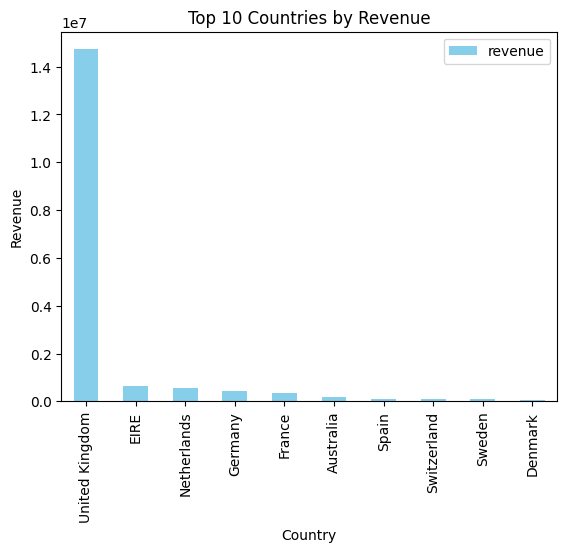

In [ ]:
plt.figure(figsize=(12,6))
Country_Sales.plot(kind='bar', x='Country', y='revenue', color='skyblue')
plt.xticks(rotation=90)
plt.title('Top 10 Countries by Revenue')
plt.xlabel('Country')
plt.ylabel('Revenue')
plt.show()

EDA 3: Top 10 Products

In [ ]:
Top_Products= df.groupby('Description')['revenue'].sum().sort_values(ascending=False).head(10).reset_index()
print(Top_Products)

                          Description    revenue
0            REGENCY CAKESTAND 3 TIER  286486.30
1  WHITE HANGING HEART T-LIGHT HOLDER  252072.46
2         PAPER CRAFT , LITTLE BIRDIE  168469.60
3                              Manual  152340.57
4             JUMBO BAG RED RETROSPOT  136980.08
5       ASSORTED COLOUR BIRD ORNAMENT  127074.17
6                             POSTAGE  126563.04
7                       PARTY BUNTING  103880.23
8      MEDIUM CERAMIC TOP STORAGE JAR   81416.73
9     PAPER CHAIN KIT 50'S CHRISTMAS    79594.33


<Figure size 1200x600 with 0 Axes>

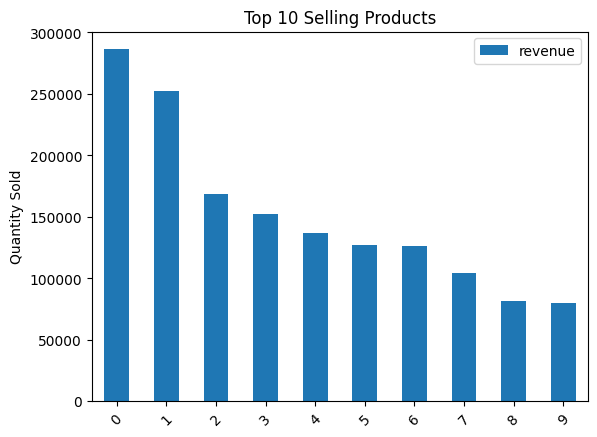

In [ ]:
plt.figure(figsize=(12,6))

Top_Products.plot(kind='bar')

plt.title("Top 10 Selling Products")

plt.ylabel("Quantity Sold")

plt.xticks(rotation=45)

plt.show()

EDA 4: Revenue Distribution

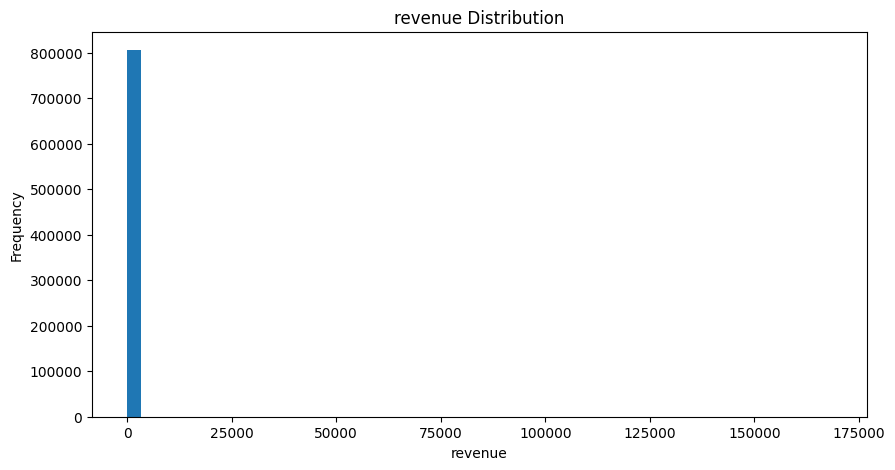

In [ ]:
plt.figure(figsize=(10,5))

plt.hist(df['revenue'], bins=50)

plt.title("revenue Distribution")

plt.xlabel("revenue")

plt.ylabel("Frequency")

plt.show()

EDA 5: Orders by Country

In [ ]:
country_orders = df.groupby('Country')['Invoice'].count().sort_values(ascending=False).head(10)

country_orders

,Invoice
Country,
United Kingdom,725250
Germany,16694
EIRE,15743
France,13812
Netherlands,5088
Spain,3719
Belgium,3068
Switzerland,3011
Portugal,2446


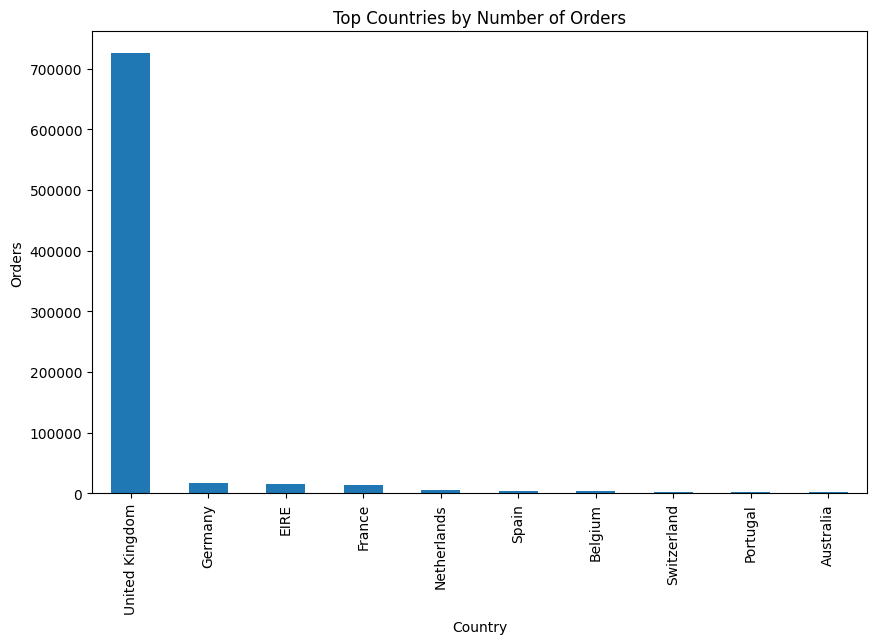

In [ ]:
plt.figure(figsize=(10,6))

country_orders.plot(kind='bar')

plt.title("Top Countries by Number of Orders")

plt.ylabel("Orders")

plt.show()

EDA 6: Top Customers

In [ ]:
top_customers = (
    df.groupby('Customer ID')['revenue']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_customers

,revenue
Customer ID,
18102,608821.65
14646,528602.52
14156,313946.37
14911,295972.63
17450,246973.09
13694,196482.81
17511,175603.55
16446,168472.50
16684,147142.77


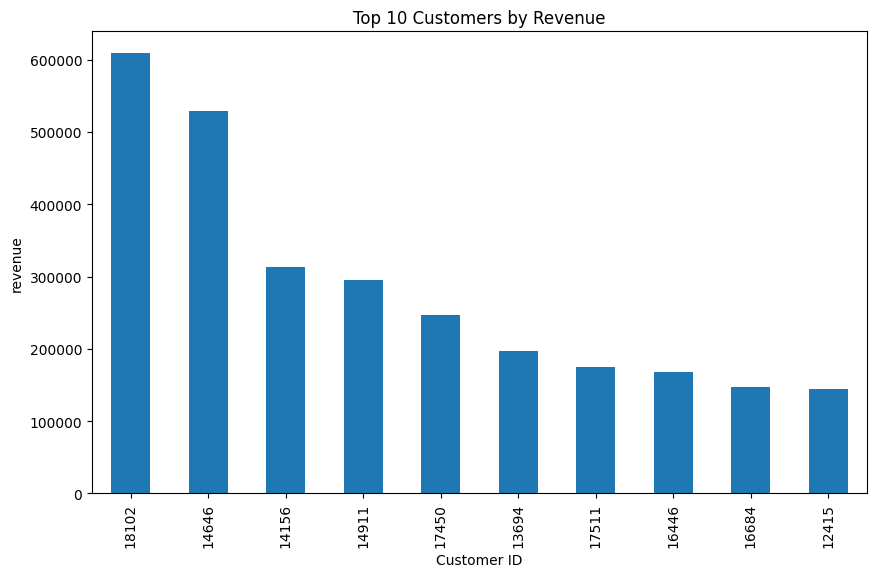

In [ ]:
plt.figure(figsize=(10,6))

top_customers.plot(kind='bar')

plt.title("Top 10 Customers by Revenue")

plt.ylabel("revenue")

plt.show()

EDA 7: Monthly Orders

In [ ]:
monthly_orders = (
    df.groupby('InvoiceMonthYear')['Invoice']
      .nunique()
      .reset_index()
)

monthly_orders

,InvoiceMonthYear,Invoice
0,2009-12,1512
1,2010-01,1011
2,2010-02,1104
3,2010-03,1524
4,2010-04,1329
5,2010-05,1377
6,2010-06,1497
7,2010-07,1381
8,2010-08,1293
9,2010-09,1689


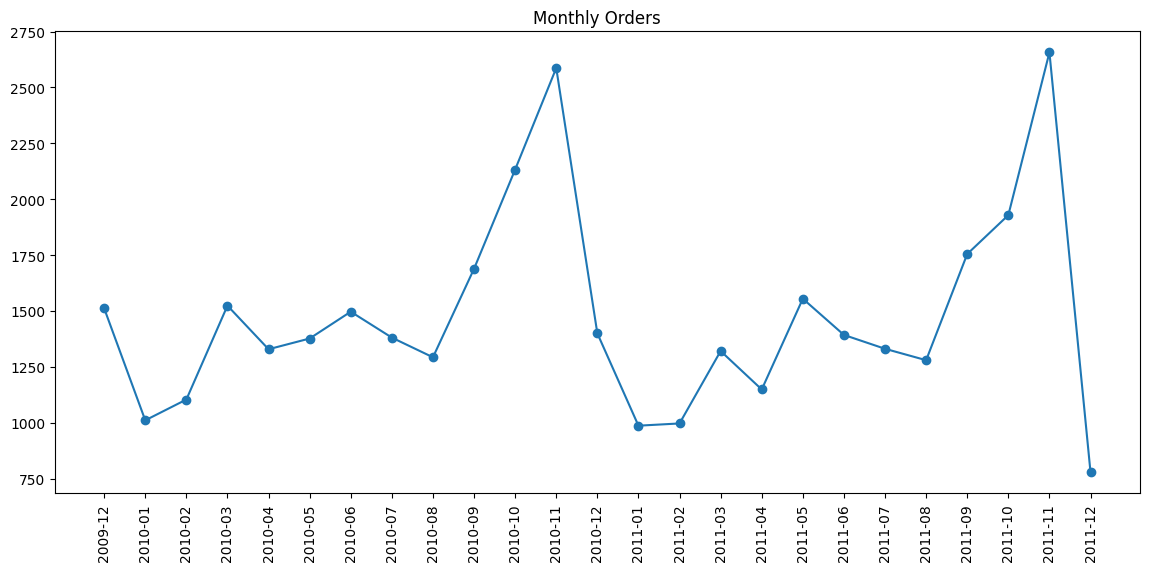

In [ ]:
plt.figure(figsize=(14,6))

plt.plot(
    monthly_orders['InvoiceMonthYear'].astype(str),
    monthly_orders['Invoice'],
    marker='o'
)

plt.xticks(rotation=90)

plt.title("Monthly Orders")

plt.show()

EDA 8: Correlation Analysis

In [ ]:
correlation = df[['Quantity','Price','revenue']].corr()

correlation

,Quantity,Price,revenue
Quantity,1.000000,-0.004909,0.826590
Price,-0.004909,1.000000,0.135897
revenue,0.826590,0.135897,1.000000


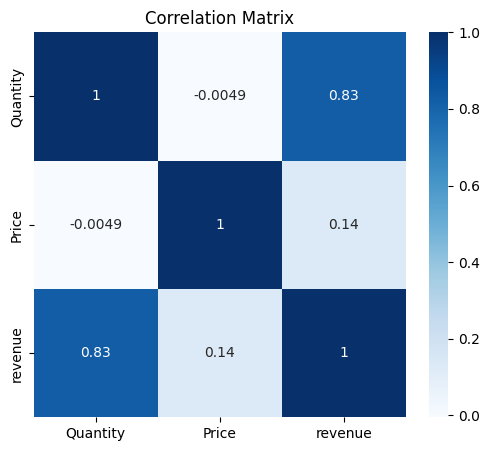

In [ ]:
plt.figure(figsize=(6,5))

sns.heatmap(correlation,
            annot=True,
            cmap='Blues')

plt.title("Correlation Matrix")

plt.show()

8. Customer Analytics

8.1 Customer Lifetime Value (CLV)
Which customers have generated the highest revenue?

In [ ]:
customer_clv = (
    df.groupby('Customer ID')
      .agg(
    total_revenue=('revenue','sum'),
    total_orders=('Invoice','unique'),
    total_items=('Quantity','sum')
)
.reset_index()
)
customer_clv.sort_values(by='total_revenue', ascending=False).head(10)

,Customer ID,total_revenue,total_orders,total_items
5692,18102,608821.65,"[489438, 490059, 490061, 491456, 492236, 49223...",188340
2277,14646,528602.52,"[489889, 489890, 490964, 492248, 492724, 49414...",367193
1789,14156,313946.37,"[489546, 489550, 490127, 492092, 492251, 49275...",165992
2538,14911,295972.63,"[489520, 490542, 490687, 490972, 491160, 49201...",149987
5050,17450,246973.09,"[524181, 524182, 524288, 528951, 529350, 53744...",84720
1331,13694,196482.81,"[490320, 490324, 490327, 490725, 490726, 49181...",189205
5109,17511,175603.55,"[489702, 491800, 494875, 498163, 499009, 50147...",119656
4061,16446,168472.50,"[553573, 581483]",80997
4295,16684,147142.77,"[490671, 490672, 492133, 494678, 496355, 49917...",104810
68,12415,144458.37,"[513987, 516120, 517631, 527350, 528168, 53066...",91447


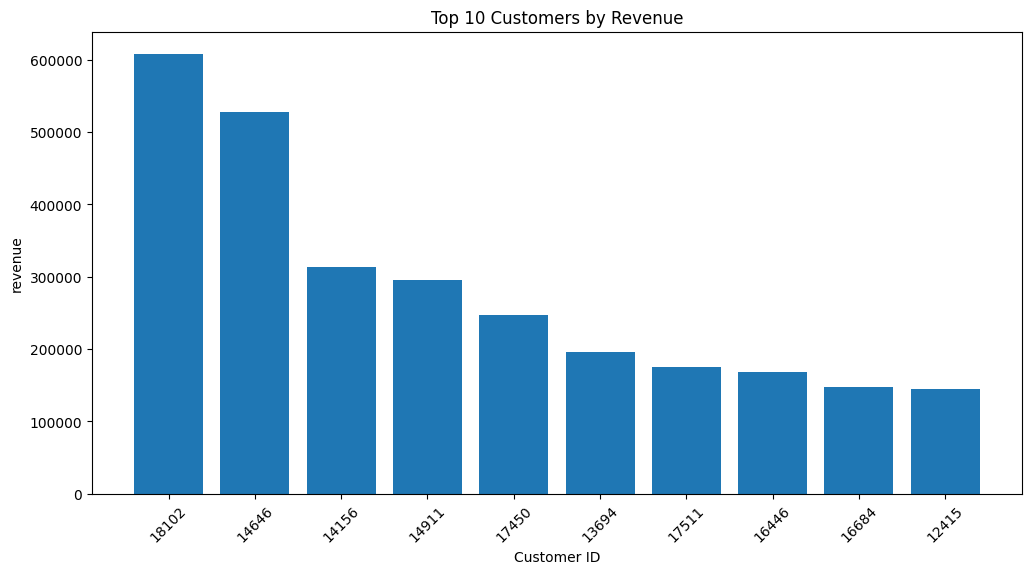

In [ ]:
top10_clv = customer_clv.nlargest(10, 'total_revenue')

plt.figure(figsize=(12,6))

plt.bar(
    top10_clv['Customer ID'].astype(str),
    top10_clv['total_revenue']
)

plt.title("Top 10 Customers by Revenue")
plt.xlabel("Customer ID")
plt.ylabel("revenue")

plt.xticks(rotation=45)

plt.show()

8.2 Purchase Frequency Distribution
Business Question

How often do customers purchase?

In [ ]:
purchase_frequency = (
    df.groupby('Customer ID')['Invoice']
      .nunique()
      .reset_index(name='Total_Orders')
)

purchase_frequency.head()

,Customer ID,Total_Orders
0,12346,12
1,12347,8
2,12348,5
3,12349,4
4,12350,1
